### Preamble

In [ ]:
try:
    import pgmuvi
except (ImportError, ModuleNotFoundError):
    %pip install -q git+https://github.com/ICSM/pgmuvi.git
    import pgmuvi

### Installation and initializations

In [ ]:
!git config --global user.email "s.srinivasan@irya.unam.mx"
!git config --global user.name "Sundar Srinivasan"
!git clone https://github.com/ICSM/pgmuvi.git pgmuvi
%cd pgmuvi
!git checkout -b test-combined main
!git merge --no-edit origin/copilot/fix-peak-ranking-logic
!git merge --no-edit origin/copilot/modify-x-axis-limits-centering
!git merge --no-edit origin/copilot/redesign-select-bands-method
!git merge --no-edit origin/copilot/implement-drop-bands-method
!git merge --no-edit origin/copilot/add-merge-and-concat-methods
!git merge --no-edit origin/copilot/check-psd-panels-log-scale
!git merge --no-edit origin/copilot/add-lightcurve-to-csv-method
!git merge --no-edit origin/copilot/add-band-attribute-to-lightcurve-again
!git merge --no-edit origin/copilot/fix-stetson-threshold-logic
!git merge --no-edit origin/copilot/fix-lightcurve-merge-band-attribute
!pip install -q -e .

Cloning into 'pgmuvi'...
remote: Enumerating objects: 3537, done.
remote: Counting objects: 100% (1092/1092), done.
remote: Compressing objects: 100% (292/292), done.
remote: Total 3537 (delta 994), reused 836 (delta 800), pack-reused 2445 (from 1)
Receiving objects: 100% (3537/3537), 4.04 MiB | 12.24 MiB/s, done.
Resolving deltas: 100% (2514/2514), done.
/content/pgmuvi
Switched to a new branch 'test-combined'
Auto-merging pgmuvi/lightcurve.py
Merge made by the 'ort' strategy.
 pgmuvi/lightcurve.py                | 211 +++++++++--
 tests/test_peak_ranking_physical.py | 712 ++++++++++++++++++++++++++++++++++++
 tests/test_period_summary.py        |  25 +-
 tests/test_period_summary_peaks.py  |  28 +-
 4 files changed, 932 insertions(+), 44 deletions(-)
 create mode 100644 tests/test_peak_ranking_physical.py
Auto-merging pgmuvi/lightcurve.py
Merge made by the 'ort' strategy.
 pgmuvi/lightcurve.py         | 28 +++++++++++------
 tests/test_2d_integration.py | 72 +++++++++++++++++++++++++

In [ ]:
# Imports and seeds for reproducibility
import gpytorch
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood

seed = 0
import torch
torch.manual_seed(seed)

import numpy as np
np.random.seed(seed)

import random
random.seed(seed)

from pgmuvi.lightcurve import Lightcurve
from gpytorch.constraints import Interval
import pgmuvi.gps as gps
from pgmuvi import synthetic
from pgmuvi.preprocess import subsample_lightcurve

SEED = 0
TRAINING_ITER = 1000
DTYPE = torch.float64
DEVICE = torch.device("cpu")

### The `Lightcurve` object

##### The central object in `pgmuvi` is the `Lightcurve` class. It can store either a light curve defined for a single wavelength (a "1D light curve") or a set of light curves defined at various wavelengths (a "2D light curve").

##### At the very least, the `Lightcurve` object will contain two arrays: the timestamps, stored in the `xdata` array, and the fluxes, stored in the `ydata` array. If flux uncertainties are available, they are stored in the `yerr` array. An optional array, `band`, stores unique string identifiers for each unique wavelength value. This array becomes important especially when manipulating 2D light curves.

##### A `Lightcurve` object can be instantiated either by providing it the `xdata`, `ydata`, and `yerr` values directly, or by providing a CSV file which contains these values.

### In this notebook, we will demonstrate some features available for Lightcurve objects to manipulate 1D and 2D light curve data.

### Generating synthetic data

##### Synthetic data can of course be generated manually, but PGMUVI also has built-in methods to generate such data. We will demonstrate both these methods below.

The following generates a 1D light curve with data generated manually

In [ ]:
""" Manual method: generate a perturbed sine curve with one period component"""

P = np.random.uniform(30, 300)  # 137. #Days!
print("True period: ", P, " days")
n_data = 400
jd_min = 2450000
n_periods = np.random.uniform(3, 10)
jd_max = jd_min + P * (n_periods)
print("Simulating for ", n_periods, " periods")

# generate data from a simple case - superimpose two sine curves and add noise
timestamps_1d = torch.Tensor(
    np.random.uniform(jd_min, jd_max, size=n_data)
)  # generate random x data here
fluxes_1d = torch.sin(timestamps_1d * (2 * np.pi / P))  # generate random y data here
fluxes_1d += 0.1 * torch.randn_like(fluxes_1d)
flux_err_1d = 0.1 * fluxes_1d.abs()

lc1d_manual = Lightcurve(timestamps_1d, fluxes_1d, yerr=flux_err_1d)

True period:  178.17964606037768  days
Simulating for  8.006325564606936  periods


We can use the `synthetic.py` script instead. The following generates a 2D light curve with a single period component

In [ ]:
"""Generate a set of mono-periodic light curves using synthetic.py"""

n_per_band = (25, 40) # number of data points per light curve limited to this range

SINGLE_DATASET_CONFIG = dict(
    period=150,
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2], # wavelengths in µm
    amplitude_law="extinction",
    seed=SEED,
)

lc2d_synth_1comp = synthetic.make_chromatic_sinusoid_2d(**SINGLE_DATASET_CONFIG)

`synthetic.py` also generates a multi-component 2D light curve. The following creates a set of light curves with 2 components and a phase lag.

In [ ]:
""" Generate a set of light curves with two period components and a phase lag"""
n_per_band = (25, 40) # number of data points per light curve limited to this range

MULTI_DATASET_CONFIG = dict(
    components=[
        {"period": 150.0, "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": 66.0, "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.8, 1.2, 2.2],
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED,
)

lc2d_synth_2comp = synthetic.make_multi_sinusoid_chromatic_2d(**MULTI_DATASET_CONFIG)

### Visualization using the `.plot()` method

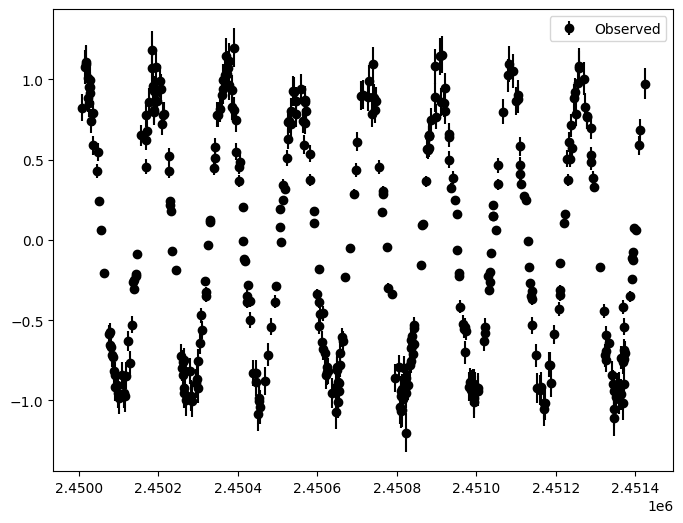

In [ ]:
_ = lc1d_manual.plot()

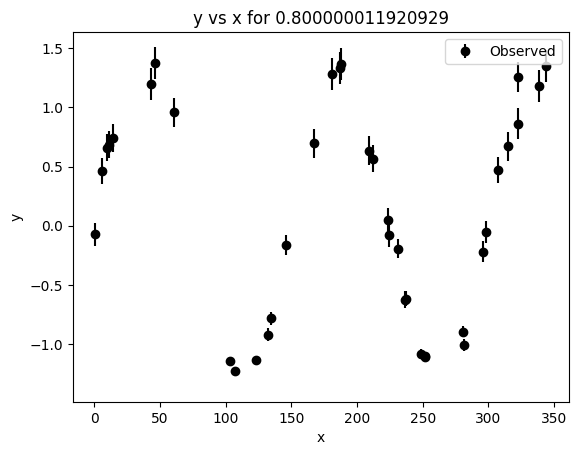

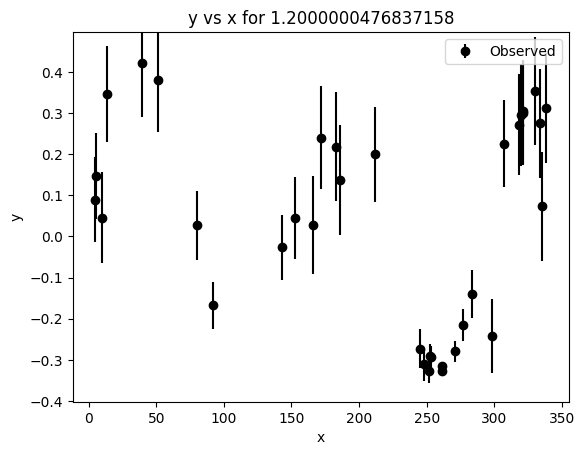

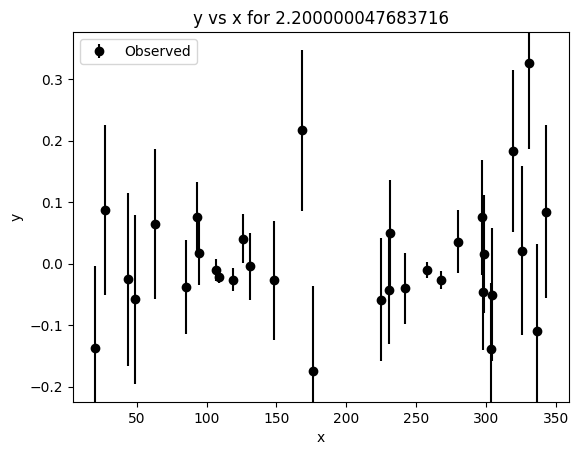

In [ ]:
_ = lc2d_synth_1comp.plot()

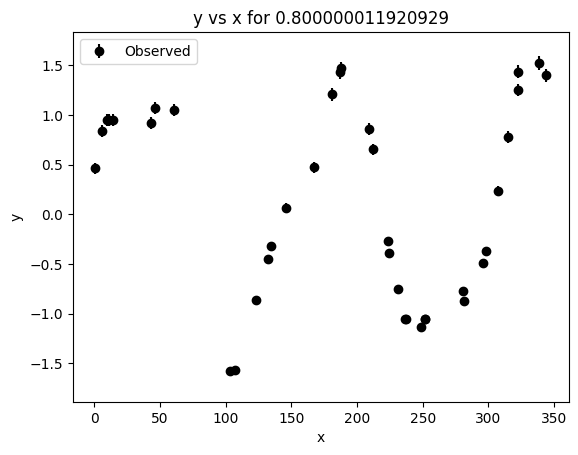

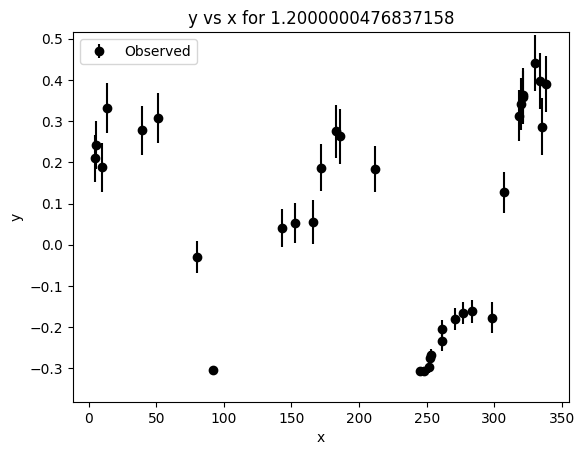

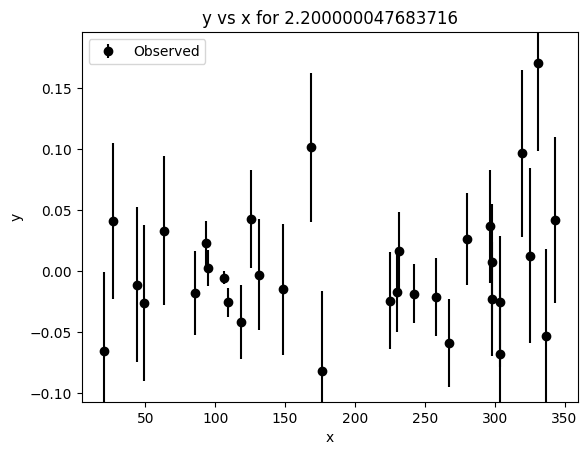

In [ ]:
_ = lc2d_synth_2comp.plot()

### Input/output to CSV

##### We can use the `.from_csv()` and `.to_csv()` methods:

In [ ]:
lc1d_manual.to_csv("lc1d_manual.csv")
lc_read = Lightcurve.from_csv("lc1d_manual.csv")

### The `band` attribute; selecting, dropping, merging, and concatenating light curves.

##### A 2D Lightcurve object is a collection of light curves at different wavelengths. The wavelengths must be available in `Lightcurve.xdata[:, 1]`, and they can be used to decompose the `Lightcurve` object into light curves at each wavelength. However, it is much more convenient to include a unique string identifier for each wavelength rather than perform float comparisons. The `band` attribute is used for this purpose, and it allows us to manipulate 2D light curves in many ways, as demonstrated below.

##### Populating the `band` attribute
##### `band` can be populated as follows if it doesn't already exist

In [ ]:
bands = ['band 1', 'band 2', 'band 3']
u, c = np.unique(lc2d_synth_1comp.xdata[:, 1], return_counts=True)
ks = np.argsort(u)
band_value = np.repeat('band 1', lc2d_synth_1comp.xdata[:, 1].shape)
for uu in u[ks]:
  idx = np.where(lc2d_synth_1comp.xdata[:, 1] == uu)[0]
  band_value[idx] = bands[ks[np.where(u == uu)[0][0]]]

lc2d_synth_1comp.band = band_value

###### We can now write the updated Lightcurve object to a file for posterity

In [ ]:
_ = lc2d_synth_1comp.to_csv("lightcurve_band123.csv")

##### `select_bands`

##### Once a `band` attribute is available, we can select a subset of light curve into a new Lightcurve object:

In [ ]:
lc23 = lc2d_synth_1comp.select_bands(['band 2', 'band 3'])
print(f"No. of observations in lc2d_synth_1comp: {lc2d_synth_1comp.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc2d_synth_1comp.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

print(f"No. of observations in lc23: {lc23.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc23.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc2d_synth_1comp: torch.Size([106])
Breakdown by band:
band 1 38
band 2 35
band 3 33
No. of observations in lc23: torch.Size([68])
Breakdown by band:
band 2 35
band 3 33


##### `drop_bands`
##### We can also create a Lightcurve object by removing one or more bands from the original:

In [ ]:
lc1 = lc2d_synth_1comp.drop_bands(['band 2', 'band 3'])
print(f"No. of observations in lc1: {lc1.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc1.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc1: torch.Size([38])
Breakdown by band:
band 1 38


##### `merge`
##### Data from a Lightcurve object can be merged into another:

In [ ]:
lc123 = lc23.merge(lc1)
print(f"No. of observations in lc123: {lc123.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc123.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc123: torch.Size([106])
Breakdown by band:
band 1 38
band 2 35
band 3 33


###### The merge method also accepts a CSV file name as an argument, and reads in the data to merge into the existing Lightcurve object:

In [ ]:
lc23.to_csv('lightcurve_band23.csv')
lc123 = lc1.merge("lightcurve_band23.csv")
print(f"No. of observations in lc123: {lc123.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc123.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc123: torch.Size([106])
Breakdown by band:
band 1 38
band 2 35
band 3 33


###### In the case that the CSV file contains a 1-D light curve, the `wavelength` value must be passed as an input argument:

In [ ]:
lc1.to_csv("lightcurve_band1.csv")
lc123 = lc23.merge("lightcurve_band1.csv", wavelength=0.8)
print(f"No. of observations in lc123: {lc123.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc123.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc123: torch.Size([106])
Breakdown by band:
b 38
band 2 35
band 3 33


##### `concat`

##### When we want to combine data from multiple Lightcurve objects or CSV files, we can use `concat` instead. Note that this method only accepts CSV files containing 2-D light curves. 1-D light curves must be supplied as Lightcurve objects.

In [ ]:
lc123 = Lightcurve.concat([lc1, lc23])
lc123 = Lightcurve.concat(["lightcurve_band23.csv", lc1])

###### `concat` checks for duplicate data. The following will throw a `ValueError`:

In [ ]:
lc_1 = lc1
lc123 = Lightcurve.concat([lc1, lc23, lc_1])

ValueError: Conflict detected: band np.str_('band 1') appears in more than one input. Use on_conflict='skip' to skip conflicting bands.

###### `on_conflict` is set to `"raise"` by default so the user can be made aware of the duplicate data. Set it to `"skip"` to automatically skip over duplicate bands. This will display a `UserWarning`:

In [ ]:
lc_1 = lc1
lc123 = Lightcurve.concat([lc1, lc23, lc_1], on_conflict="skip")

### Subsampling light curves

##### The execution time for both the `fit_LS` and `fit` methods increases with the total number of data points in the Lightcurve object. It is often convenient to subsample light curves that may have a large number of data points, while preserving the overall information in the light curve. The `Lightcurve` object offers a procedure for this that can be accessed in various ways.

##### We will demonstrate subsampling on a light curve with a large number of points. We will also demonstrate how subsampling works with a 2D `Lightcurve` object.

/content/pgmuvi/pgmuvi/synthetic.py:907: UserWarning: Lightcurve has 9253 points, which exceeds max_samples=1000. Execution may be slow. Consider setting max_samples_per_band to reduce the total size of the lightcurve.
  return Lightcurve(x, y, yerr=yerr)


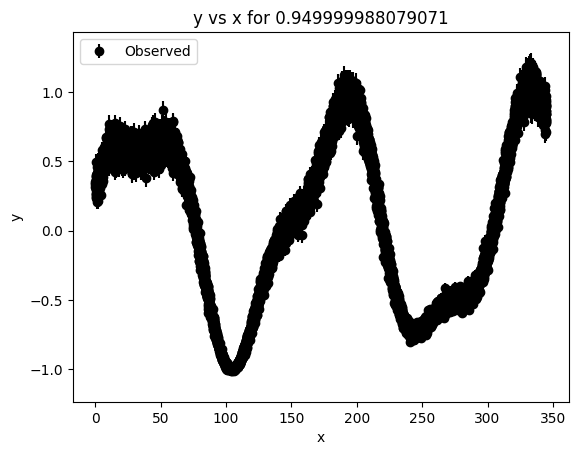

[<Figure size 640x480 with 1 Axes>]

In [ ]:
# Generate a light curve at a new wavelength with a large number of data points

n_per_band = (5000, 10000) # number of data points per light curve limited to this range

# generate a set of light curves with two period components and a phase lag
# dataset_type="make_multi_sinusoid_chromatic_2d", # series of synthetic light curves with two period components and a phase lag
MULTI_DATASET_CONFIG = dict(
    components=[
        {"period": 150.0, "amplitude_fraction": 1.0, "phase": 0.0},
        {"period": 66.0, "amplitude_fraction": 0.3, "phase": np.pi / 2 * 0.85},
    ],
    t_span=150 * 2.3,
    n_per_band=n_per_band,
    wavelengths=[0.95],
    amplitude_law="extinction",
    noise_level=0.05,
    seed=SEED,
)

lc1_5 = synthetic.make_multi_sinusoid_chromatic_2d(**MULTI_DATASET_CONFIG)
lc1_5.band = np.repeat('band 1.5', lc1_5.xdata[:, 0].shape)
lc1_5.plot()

###### Note the `UserWarning` that already suggests adjusting two arguments: `max_samples` and `max_samples_per_band`. These are explained below.

Let us first merge this new light curve into the existing data:

In [ ]:
lc123 = Lightcurve.from_csv("lightcurve_band123.csv")

lc1234 = lc123.merge(lc1_5)
print(lc1234.xdata.shape)
print(np.unique(lc1234.band))

torch.Size([9359, 2])
['band 1' 'band 1.5' 'band 2' 'band 3']


/content/pgmuvi/pgmuvi/lightcurve.py:10690: UserWarning: Lightcurve has 9359 points, which exceeds max_samples=1000. Execution may be slow. Consider setting max_samples_per_band to reduce the total size of the lightcurve.
  return Lightcurve(


##### PGMUVI can generate a report summarising the sampling quality of the data. Based on various criteria (see `preprocess/quality.py`), the code suggests whether a band should be included when executing `fit_LS` or `fit`.

In [ ]:
lc1234.assess_sampling_quality_per_band()


BAND: λ = 0.800000011920929
LIGHTCURVE SAMPLING QUALITY ASSESSMENT

Temporal Coverage:
  • Points: 38
  • Baseline: 343.09 time units
  • Median cadence: 5.649
  • Max gap: 42.80 (12.5% of baseline)
  • Sampling uniformity: 0.000

Detectable Period Range:
  • Nyquist (shortest): 11.30
  • Longest: 171.55

Signal Quality:
  • Median SNR: 8.8
  • Points with SNR > 3: 82%
  • Points with SNR > 5: 74%

Quality Gates:
  ✓ min_points: PASS
  ✓ max_gap: PASS
  ✓ min_baseline: PASS
  ✓ min_snr: PASS

Recommendation: PROCEED


BAND: λ = 0.949999988079071
LIGHTCURVE SAMPLING QUALITY ASSESSMENT

Temporal Coverage:
  • Points: 9253
  • Baseline: 344.96 time units
  • Median cadence: 0.026
  • Max gap: 0.39 (0.1% of baseline)
  • Sampling uniformity: 0.020

Detectable Period Range:
  • Nyquist (shortest): 0.05
  • Longest: 172.48

Signal Quality:
  • Median SNR: 10.7
  • Points with SNR > 3: 89%
  • Points with SNR > 5: 83%

Quality Gates:
  ✓ min_points: PASS
  ✓ max_gap: PASS
  ✓ min_baseline: P

{0.800000011920929: {'metrics': {'n_points': 38,
   'baseline': 343.0926208496094,
   'max_gap': 42.799415588378906,
   'max_gap_fraction': 0.1247459519309788,
   'median_cadence': 5.64923095703125,
   'mean_cadence': 9.272774696350098,
   'cadence_std': 9.400240898132324,
   'nyquist_period': 11.2984619140625,
   'nyquist_frequency': 0.08850762233002366,
   'longest_detectable_period': 171.5463104248047,
   'duty_cycle': 0.6256933647701095,
   'sampling_uniformity': 0.0,
   'median_snr': 8.806802749633789,
   'mean_snr': 14.792816162109375,
   'fraction_snr_gt_3': 0.8157894736842105,
   'fraction_snr_gt_5': 0.7368421052631579,
   'snr_values': array([  0.74203444,   4.3450656 ,   5.8211846 ,   5.9025126 ,
            6.206423  ,   8.893876  ,  10.331533  ,   7.981411  ,
           50.212803  , 127.438515  ,  39.826546  ,  17.175508  ,
           13.402588  ,   1.8981013 ,   5.620891  ,   9.540076  ,
            9.812996  ,  10.082142  ,   5.2171683 ,   4.8273406 ,
            0.489511

##### A single light curve can be subsampled as follows:

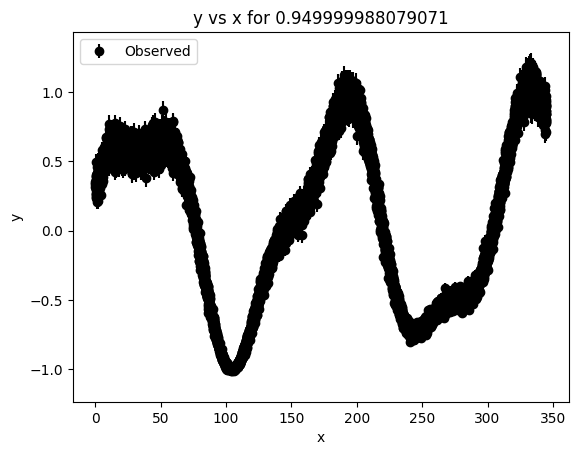

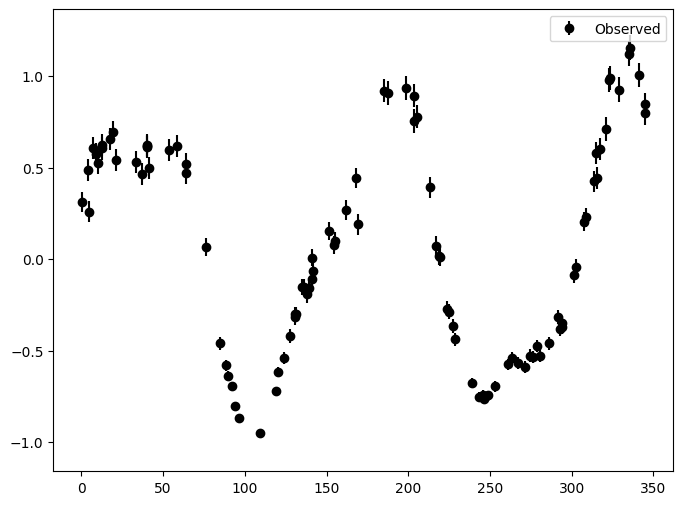

In [ ]:
idx = subsample_lightcurve(lc1_5.xdata[:, 0], max_samples=100)
lc_sub = Lightcurve(xdata=lc1_5.xdata[idx, 0], ydata=lc1_5.ydata[idx],
                    yerr=lc1_5.yerr[idx], band=[lc1_5.band[idx[0]]])
_ = lc1_5.plot()
_ = lc_sub.plot()

##### The `max_samples_per_band` argument determines which bands in a 2D `Lightcurve` object need to be subsampled. Bands with fewer than `max_samples_per_band` points are left unchanged, UNLESS the total number of observations (set by `max_samples`) is exceeded even after subsampling. If this happens, all bands in the `Lightcurve` object may be subsampled. To avoid this, `max_samples` can be set to a high value. However, this will slow down the execution of `fit_LS` and `fit`.

In [ ]:
_ = lc1234.to_csv("lightcurve_bands1234.csv")
print(f"No. of observations in lc1234: {lc1234.xdata[:, 1].shape}")
print("Breakdown by band:")
u, c = np.unique(lc1234.band, return_counts=True)
for uu, cc in zip(u, c):
  print(uu, cc)

No. of observations in lc1234: torch.Size([9359])
Breakdown by band:
band 1 38
band 1.5 9253
band 2 35
band 3 33


###### We set `max_samples` such that subsampling is only applied to the band that actually needs it:

In [ ]:
lc = Lightcurve.from_csv("lightcurve_bands1234.csv", max_samples=1000,
                         max_samples_per_band=98)

/content/pgmuvi/pgmuvi/lightcurve.py:804: UserWarning: The following bands exceed max_samples_per_band=98 and were randomly subsampled: λ=0.949999988079071. Set max_samples_per_band=None to disable subsampling.
The subsampled 2D light curve has the following structure:
    λ=0.800000011920929: 38 points
    λ=0.949999988079071: 98 points
    λ=1.2000000476837158: 35 points
    λ=2.200000047683716: 33 points
  return cls(xdata=x, ydata=y, yerr=yerr, **kwargs)


##### We can visualize the subsampled `Lightcurve` object:

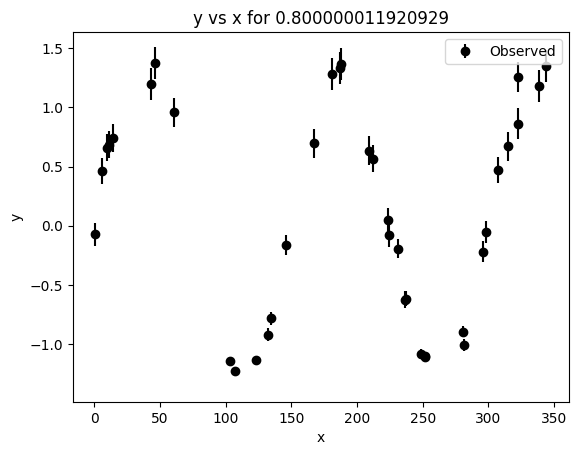

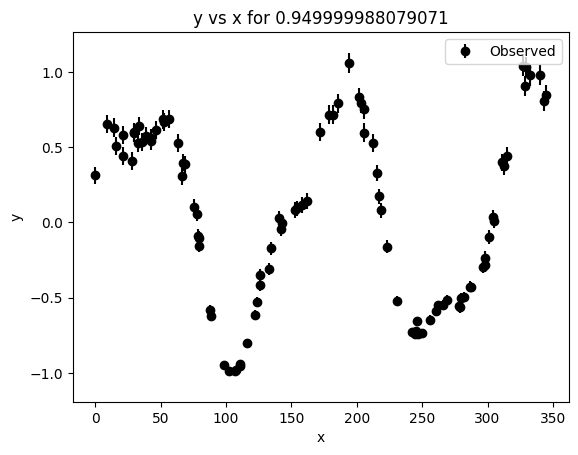

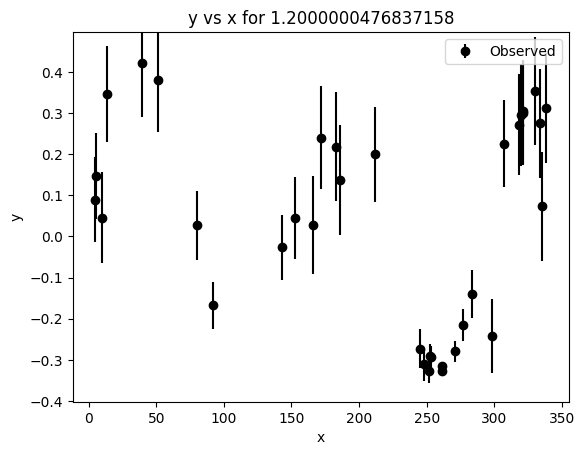

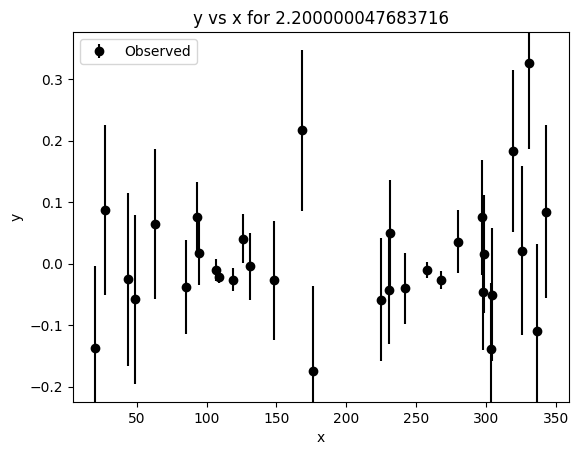

In [ ]:
_ = lc.plot()

### Statistical tests for variability

##### PGMUVI also runs simple statistical tests in order to determine whether the light curve at a given wavelength is indeed variable. This can be used to avoid computing fits to bands that do not have statistically significant variability.

##### The following shows that the light curve at the longest wavelength suffers from low signal-to-noise and therefore offers insufficient evidence of variability (this is also clear from the plot above).


In [ ]:
lc1234.check_variability_per_band()

{0.800000011920929: {'n_points': 38,
  'chi2': 5971.863755049171,
  'dof': 37,
  'p_value': 0.0,
  'fvar': 6.291265641676324,
  'stetson_k': 0.8903669154361761,
  'decision': 'VARIABLE; DIAGNOSTIC: stetson_k=0.890<ref=0.950',
  'tests_passed': {'chi2_test': True,
   'fvar_test': True,
   'stetson_test': False,
   'min_points': True}},
 0.949999988079071: {'n_points': 9253,
  'chi2': 3085250.6233217064,
  'dof': 9252,
  'p_value': 0.0,
  'fvar': 7.141045327941416,
  'stetson_k': 0.8532113521607533,
  'decision': 'VARIABLE; DIAGNOSTIC: stetson_k=0.853<ref=0.950',
  'tests_passed': {'chi2_test': True,
   'fvar_test': True,
   'stetson_test': False,
   'min_points': True}},
 1.2000000476837158: {'n_points': 35,
  'chi2': 450.62216558296944,
  'dof': 34,
  'p_value': 3.1942924242578224e-74,
  'fvar': 5.267336962486132,
  'stetson_k': 0.8925604260495829,
  'decision': 'VARIABLE; DIAGNOSTIC: stetson_k=0.893<ref=0.950',
  'tests_passed': {'chi2_test': True,
   'fvar_test': True,
   'stetson_te